In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Pretraining BERT

With the BERT model implemented in that section
and the pretraining examples generated from the WikiText-2 dataset in that section, we will pretrain BERT on the WikiText-2 dataset in this section.

In [1]:
from d2l import jax as d2l
import jax
from jax import numpy as jnp
from flax import nnx
import optax
import numpy as np

To start, we load the WikiText-2 dataset as minibatches
of pretraining examples for masked language modeling and next sentence prediction.
The batch size is 512 and the maximum length of a BERT input sequence is 64.
Note that in the original BERT model, the maximum length is 512.

In [2]:
batch_size, max_len = 512, 64
# In JAX, train_iter is a callable returning a fresh iterator each call.
train_iter, vocab = d2l.load_data_wiki(batch_size, max_len)

## Pretraining BERT

The original BERT has two versions of different model sizes [@Devlin.Chang.Lee.ea.2018].
The base model ($\textrm{BERT}_{\textrm{BASE}}$) uses 12 layers (Transformer encoder blocks)
with 768 hidden units (hidden size) and 12 self-attention heads.
The large model ($\textrm{BERT}_{\textrm{LARGE}}$) uses 24 layers
with 1024 hidden units and 16 self-attention heads.
Notably, the former has 110 million parameters while the latter has 340 million parameters.
For demonstration with ease,
we define a small BERT, using 2 layers, 128 hidden units, and 2 self-attention heads.

In [3]:
net = d2l.BERTModel(len(vocab), num_hiddens=128,
                    ffn_num_hiddens=256, num_heads=2, num_blks=2, dropout=0.2)

Before defining the training loop,
we define a helper function `_get_batch_loss_bert`.
Given the shard of training examples,
this function computes the loss for both the masked language modeling and next sentence prediction tasks.
Note that the final loss of BERT pretraining
is just the sum of both the masked language modeling loss
and the next sentence prediction loss.

In [4]:

def _get_batch_loss_bert(net, vocab_size, tokens_X,
                         segments_X, valid_lens_x,
                         pred_positions_X, mlm_weights_X,
                         mlm_Y, nsp_y):
    # Forward pass
    _, mlm_Y_hat, nsp_Y_hat = net(tokens_X, segments_X,
                                  valid_lens_x.reshape(-1),
                                  pred_positions_X)
    # Compute masked language model loss
    mlm_l = optax.softmax_cross_entropy_with_integer_labels(
        mlm_Y_hat.reshape(-1, vocab_size), mlm_Y.reshape(-1))
    mlm_l = (mlm_l * mlm_weights_X.reshape(-1)).sum() / (
        mlm_weights_X.sum() + 1e-8)
    # Compute next sentence prediction loss
    nsp_l = optax.softmax_cross_entropy_with_integer_labels(
        nsp_Y_hat, nsp_y).mean()
    l = mlm_l + nsp_l
    return l, (mlm_l, nsp_l)

Invoking the two aforementioned helper functions,
the following `train_bert` function
defines the procedure to pretrain BERT (`net`) on the WikiText-2 (`train_iter`) dataset.
Training BERT can take very long.
Instead of specifying the number of epochs for training
as in the `train_ch13` function (see that section),
the input `num_steps` of the following function
specifies the number of iteration steps for training.

In [5]:
def train_bert(train_iter, net, vocab_size, num_steps):
    optimizer = nnx.Optimizer(net, optax.adam(learning_rate=1e-4),
                              wrt=nnx.Param)

    @nnx.jit
    def train_step(net, optimizer, batch):
        def loss_fn(model):
            return _get_batch_loss_bert(model, vocab_size, *batch)
        (l, (mlm_l, nsp_l)), grads = nnx.value_and_grad(
            loss_fn, has_aux=True)(net)
        optimizer.update(net, grads)
        return l, mlm_l, nsp_l

    step, timer = 0, d2l.Timer()
    animator = d2l.Animator(xlabel='step', ylabel='loss',
                            xlim=[1, num_steps], legend=['mlm', 'nsp'])
    # Sum of masked language modeling losses, sum of next sentence prediction
    # losses, no. of sentence pairs, count
    metric = d2l.Accumulator(4)
    num_steps_reached = False
    while step < num_steps and not num_steps_reached:
        # train_iter is a callable: invoke it each epoch for a fresh iterator.
        for (tokens_X, segments_X, valid_lens_x, pred_positions_X,
            mlm_weights_X, mlm_Y, nsp_y) in train_iter():
            timer.start()
            batch = (tokens_X, segments_X, valid_lens_x, pred_positions_X,
                     mlm_weights_X, mlm_Y, nsp_y)
            _, mlm_l, nsp_l = train_step(net, optimizer, batch)
            metric.add(float(mlm_l), float(nsp_l), tokens_X.shape[0], 1)
            timer.stop()
            animator.add(step + 1,
                         (metric[0] / metric[3], metric[1] / metric[3]))
            step += 1
            if step == num_steps:
                num_steps_reached = True
                break

    print(f'MLM loss {metric[0] / metric[3]:.3f}, '
          f'NSP loss {metric[1] / metric[3]:.3f}')
    print(f'{metric[2] / timer.sum():.1f} sentence pairs/sec on '
          f'{str(jax.devices())}')
    return net

We can plot both the masked language modeling loss and the next sentence prediction loss
during BERT pretraining.
The 50-step run below is a mechanics-only smoke test for the training loop;
it is intentionally too short to produce a converged BERT model or meaningful downstream representations.

MLM loss 9.665, NSP loss 0.712
523.6 sentence pairs/sec on [CudaDevice(id=0)]


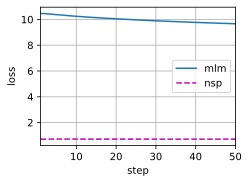

In [6]:
net = train_bert(train_iter, net, len(vocab), 50)

## Representing Text with BERT

After pretraining BERT,
we can use it to represent single text, text pairs, or any token in them.
The following function returns the BERT (`net`) representations for all tokens
in `tokens_a` and `tokens_b`.

In [7]:
def get_bert_encoding(net, tokens_a, tokens_b=None):
    tokens, segments = d2l.get_tokens_and_segments(tokens_a, tokens_b)
    token_ids = jnp.array(vocab[tokens], dtype=jnp.int32)[None, :]
    segments = jnp.array(segments, dtype=jnp.int32)[None, :]
    valid_len = jnp.array([len(tokens)], dtype=jnp.float32)
    encoded_X, _, _ = nnx.view(net, deterministic=True)(
        token_ids, segments, valid_len)
    return encoded_X

Consider the sentence "a crane is flying".
Recall the input representation of BERT as discussed in that section.
After inserting special tokens “&lt;cls&gt;” (used for classification)
and “&lt;sep&gt;” (used for separation),
the BERT input sequence has a length of six.
Since zero is the index of the “&lt;cls&gt;” token,
`encoded_text[:, 0, :]` is the BERT representation of the entire input sentence.
To evaluate the polysemy token "crane",
we also print out the first three elements of the BERT representation of the token.

In [8]:
tokens_a = ['a', 'crane', 'is', 'flying']
encoded_text = get_bert_encoding(net, tokens_a)
# Tokens: '<cls>', 'a', 'crane', 'is', 'flying', '<sep>'
encoded_text_cls = encoded_text[:, 0, :]
encoded_text_crane = encoded_text[:, 2, :]
encoded_text.shape, encoded_text_cls.shape, encoded_text_crane[0][:3]

((1, 6, 128),
 (1, 128),
 Array([-0.48675025, -1.4178457 , -0.3135721 ], dtype=float32))

Now consider a sentence pair
"a crane driver came" and "he just left".
Similarly, `encoded_pair[:, 0, :]` is the encoded result of the entire sentence pair from the pretrained BERT.
Note that the first three elements of the polysemy token "crane" are different from those when the context is different.
This supports that BERT representations are context-sensitive.

In [9]:
tokens_a, tokens_b = ['a', 'crane', 'driver', 'came'], ['he', 'just', 'left']
encoded_pair = get_bert_encoding(net, tokens_a, tokens_b)
# Tokens: '<cls>', 'a', 'crane', 'driver', 'came', '<sep>', 'he', 'just',
# 'left', '<sep>'
encoded_pair_cls = encoded_pair[:, 0, :]
encoded_pair_crane = encoded_pair[:, 2, :]
encoded_pair.shape, encoded_pair_cls.shape, encoded_pair_crane[0][:3]

((1, 10, 128),
 (1, 128),
 Array([-0.70371836, -0.90896857, -0.1139093 ], dtype=float32))

In that section, we will fine-tune a pretrained BERT model
for downstream natural language processing applications.

## Summary

* The original BERT has two versions, where the base model has 110 million parameters and the large model has 340 million parameters.
* After pretraining BERT, we can use it to represent single text, text pairs, or any token in them.
* In the experiment, the same token has different BERT representation when their contexts are different. This supports that BERT representations are context-sensitive.


## Exercises

1. In the experiment, we can see that the masked language modeling loss is significantly higher than the next sentence prediction loss. Why?
2. Set the maximum length of a BERT input sequence to be 512 (same as the original BERT model). Use the configurations of the original BERT model such as $\textrm{BERT}_{\textrm{LARGE}}$. Do you encounter any error when running this section? Why?

[Discussions](https://d2l.discourse.group/t/1497)